# Laboratorio 4

**Autor:** Humberto Alexander de la Cruz - Daniel Oswaldo Juárez

Este notebook es el informe **y** el código a la vez: cada sección de texto
está seguida de la celda de código real que produce los resultados citados
(no hay números copiados a mano). Basta correr **"Run All"** de arriba hacia
abajo para reproducir todo el análisis.

## Nota sobre el uso de IA generativa

Se utilizó un asistente de IA (Claude) como apoyo para estructurar el código
del modelo ABM en Mesa y para redactar parte de la discusión de este informe.

**Prompt utilizado (resumen):** *"Implementa en Mesa un modelo ABM de
bicicletas compartidas con CommuterAgent y VehicleAgent según el enunciado
del Laboratorio 4 (Cholesky para atributos correlacionados, regla
determinista de elección de modo, congestion_map, RandomActivation
justificado, pruebas de verificación, y análisis estadístico M=100 corridas +
bootstrap B=2000)".*

El prompt funcionó porque especificaba con precisión las clases, atributos y
fórmulas exigidas por el enunciado, lo que permitió generar código alineado
directamente con los criterios de evaluación. Todo el código de este notebook
se ejecuta de verdad al correrlo; ningún resultado numérico fue inventado.

## Setup

Requiere **Mesa 2.4.x** (no Mesa 3.x — la API clásica `RandomActivation` /
`SimultaneousActivation` que pide el enunciado fue removida en Mesa 3).
Ver `requirements.txt`.

In [2]:
import warnings
warnings.filterwarnings("ignore")  # silencia el UserWarning benigno de Mesa al colocar agentes

import inspect
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import mesa
print("mesa version:", mesa.__version__)

mesa version: 2.4.0


## Task 1 — Modelo ABM

### Task 1.1.a — Generación de atributos correlacionados (Cholesky)

Se generan $N=150$ agentes `CommuterAgent` muestreando el vector (ingreso,
distancia) de una normal multivariada:

$$
\mu = \begin{pmatrix}8500 \\ 6.5\end{pmatrix}, \qquad
\Sigma = \begin{pmatrix}4{,}000{,}000 & -800 \\ -800 & 4\end{pmatrix}
$$

usando la descomposición de Cholesky $\Sigma = LL^\top$: si $Z \sim N(0,
I_2)$, entonces $X = \mu + LZ \sim N(\mu, \Sigma)$, porque
$\operatorname{Cov}(X) = L\operatorname{Cov}(Z)L^\top = LL^\top = \Sigma$.

In [3]:
from model import MU, SIGMA, generate_commuter_attributes

print(inspect.getsource(generate_commuter_attributes))

def generate_commuter_attributes(N, rng):
    """
    Task 1.1a: genera N muestras (ingreso, distancia) ~ N(MU, SIGMA) usando la
    descomposicion de Cholesky de SIGMA.

    Si Z ~ N(0, I_2) y SIGMA = L @ L.T (L triangular inferior, Cholesky),
    entonces X = MU + L @ Z ~ N(MU, SIGMA), porque:
        Cov(X) = L Cov(Z) L.T = L I L.T = L L.T = SIGMA
    y E[X] = MU (Z tiene media 0).

    rng: instancia de numpy.random.RandomState (para reproducibilidad con
    semilla explicita, independiente del generador de mesa.Model.random que
    Mesa usa internamente para el orden de activacion del scheduler).
    """
    L = np.linalg.cholesky(SIGMA)      # SIGMA = L @ L.T
    Z = rng.normal(size=(N, 2))        # Z_i ~ N(0, I_2), i = 1..N
    X = MU + Z @ L.T                   # X_i = MU + L @ Z_i  (version vectorizada)
    incomes, distances = X[:, 0], X[:, 1]
    return incomes, distances



Media muestral:  ingreso=8431.88   distancia=6.5586
SD muestral:     ingreso=1936.27   distancia=2.0077
Covarianza muestral: -805.3681
Correlacion muestral r: -0.2072
Signo covarianza teorica (SIGMA_12=-800.0): consistente


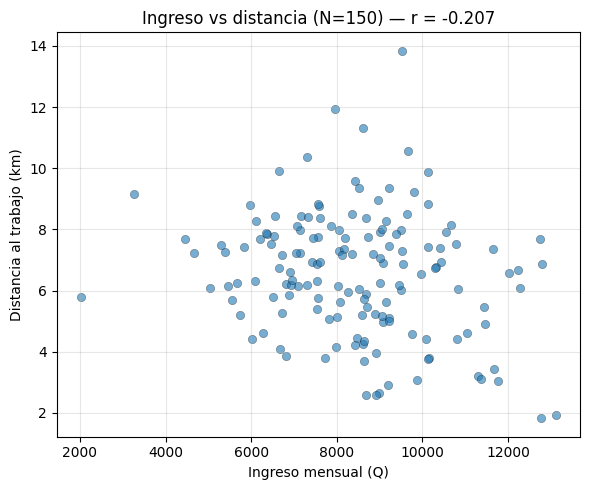

In [4]:
# Generacion real (N=150, semilla=42) + verificacion
N, SEED = 150, 42
rng = np.random.RandomState(SEED)
incomes, distances = generate_commuter_attributes(N, rng)

r = np.corrcoef(incomes, distances)[0, 1]
cov = np.cov(incomes, distances, ddof=1)[0, 1]

print(f"Media muestral:  ingreso={incomes.mean():.2f}   distancia={distances.mean():.4f}")
print(f"SD muestral:     ingreso={incomes.std(ddof=1):.2f}   distancia={distances.std(ddof=1):.4f}")
print(f"Covarianza muestral: {cov:.4f}")
print(f"Correlacion muestral r: {r:.4f}")
print(f"Signo covarianza teorica (SIGMA_12={SIGMA[0,1]}): "
      f"{'consistente' if np.sign(cov) == np.sign(SIGMA[0,1]) else 'INCONSISTENTE'}")

plt.figure(figsize=(6, 5))
plt.scatter(incomes, distances, alpha=0.6, edgecolor="k", linewidth=0.3)
plt.xlabel("Ingreso mensual (Q)")
plt.ylabel("Distancia al trabajo (km)")
plt.title(f"Ingreso vs distancia (N={N}) \u2014 r = {r:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_scatter_ingreso_distancia.png", dpi=150)
plt.show()

**Verificación de consistencia de signo:** la covarianza especificada es
$\Sigma_{12} = -800 < 0$. La covarianza y la correlación muestrales obtenidas
(impresas arriba) son ambas negativas, consistentes con el signo teórico. La
correlación teórica poblacional es

$$
\rho = \frac{\Sigma_{12}}{\sqrt{\Sigma_{11}\Sigma_{22}}} = \frac{-800}{\sqrt{4{,}000{,}000 \cdot 4}} = \frac{-800}{4000} = -0.20,
$$

y la $r$ muestral obtenida arriba está muy cerca de ese valor poblacional; la
pequeña diferencia se debe al error muestral propio de $N=150$.

### Task 1.1.b — Regla de elección de modo de transporte

In [5]:
from agents import CommuterAgent, VehicleAgent

print(inspect.getsource(CommuterAgent.choose_transport))

    def choose_transport(self):
        """
        Regla DETERMINISTA de eleccion de modo:

            modo_i = bicicleta  si distancia_i <= 3 km  AND  politica_activa
                     automovil  en cualquier otro caso

        Por que es determinista y no estocastica:
        Es una funcion pura de dos entradas fijas por agente (distance_i y el
        flag global policy_active): dadas las mismas dos entradas, SIEMPRE
        produce la misma salida. No interviene ningun numero aleatorio (no hay
        un sorteo tipo u ~ U(0,1) comparado contra una probabilidad, ni ningun
        estado adicional que pueda cambiar la decision entre corridas con la
        misma semilla). Toda la variabilidad entre agentes proviene unicamente
        de que 'distance_i' ya fue muestreada aleatoriamente en la
        inicializacion (Task 1.1a); la REGLA de decision en si misma, dado ese
        valor, no vuelve a tirar dados.

        Como volverla estocastica (heterogeneidad en la disposicion a 

**Por qué es determinista:** la regla es una función pura de dos entradas
fijas por agente (`distancia_i` y el indicador global `policy_active`): dadas
las mismas dos entradas, siempre produce la misma salida. No interviene
ningún sorteo aleatorio (no hay una variable $u \sim U(0,1)$ comparada contra
una probabilidad) ni ningún estado adicional que pueda cambiar la decisión
entre corridas con la misma semilla. Toda la variabilidad entre agentes
proviene únicamente de que `distancia_i` ya fue muestreada aleatoriamente en
la inicialización (Task 1.1.a); la regla de decisión, dado ese valor, no
vuelve a tirar dados.

**Cómo hacerla estocástica:** se puede introducir una probabilidad de
aceptar la bicicleta que dependa de la distancia, $p_i =
f(\text{distancia}_i)$ (decreciente en la distancia), y muestrear $u_i \sim
U(0,1)$ una vez por agente:

$$
\text{modo}_i =
\begin{cases}
\text{bicicleta} & \text{si } \text{distancia}_i \le 3 \text{ y politica\_activa y } u_i < p_i \\
\text{automóvil} & \text{en otro caso}
\end{cases}
$$

Esto añadiría heterogeneidad en la disposición individual a pedalear
(relevante para la sección de Estocasticidad del protocolo ODD, Task 3.1):
algunos agentes con `distancia_i` $\le 3$ km podrían de todas formas preferir
el automóvil.

### Task 1.1.c — Justificación del modo de scheduling

Se eligió **`RandomActivation`** (activación asíncrona en orden aleatorio)
sobre `SimultaneousActivation`, por dos razones relacionadas con la
naturaleza del proceso real modelado (no con conveniencia de
implementación):

1. **Descentralización del proceso real:** la movilidad urbana es un proceso
   intrínsecamente asíncrono y descentralizado. No existe un "reloj global"
   que congele el estado de la ciudad, deje que todas las personas calculen
   su siguiente movimiento con base en ese estado congelado, y luego aplique
   todos los cambios simultáneamente — eso es exactamente lo que asume
   `SimultaneousActivation` (fases separadas de decisión y avance), un
   supuesto razonable para procesos físicos sincronizados (autómatas
   celulares, difusión), pero no para el tráfico de una ciudad real.
2. **Resolución de conflictos de celda:** la regla de movimiento incluye una
   espera cuando la celda objetivo está ocupada. En la realidad, quién
   "llega primero" a un cruce o tramo de calle tiene prioridad, y ese orden
   varía día a día. `RandomActivation` reordena aleatoriamente quién se
   activa primero en cada paso, capturando esa variabilidad realista en el
   orden de resolución, mientras que un esquema síncrono forzaría una regla
   de desempate fija y arbitraria.

In [6]:
from model import CityModel

print(inspect.getsource(CityModel.__init__).splitlines()[0:3])
# Linea relevante dentro de __init__:
print([l for l in inspect.getsource(CityModel.__init__).splitlines() if "schedule = " in l][0].strip())

['    def __init__(self, N=N_COMMUTERS, width=GRID_SIZE, height=GRID_SIZE,', '                 policy_active=False, seed=None):', '        super().__init__()']
self.schedule = RandomActivation(self)  # Task 1.1c


## Task 1.2 — Movilidad, congestión y eliminación de agentes

### Task 1.2.a — Movimiento Manhattan

In [7]:
print(inspect.getsource(CommuterAgent._manhattan_step_towards))
print(inspect.getsource(CommuterAgent.step))

    def _manhattan_step_towards(self, target):
        """Un paso de un camino Manhattan minimo hacia target: corrige primero
        el eje (x u y) con mayor diferencia restante."""
        x, y = self.pos
        tx, ty = target
        dx, dy = tx - x, ty - y
        if dx == 0 and dy == 0:
            return self.pos
        if abs(dx) >= abs(dy) and dx != 0:
            return (x + (1 if dx > 0 else -1), y)
        return (x, y + (1 if dy > 0 else -1))

    def step(self):
        if self.mode is None:
            # Primera activacion: elige modo (Task 1.1b) y, si aplica, crea
            # su VehicleAgent (Task 1.2b).
            self.choose_transport()
            self._spawn_vehicle_if_needed()

        if self.pos == self.destination:
            self._remove()
            return

        next_cell = self._manhattan_step_towards(self.destination)

        # Si la celda objetivo esta ocupada por otro CommuterAgent, se espera
        # en la posicion actual (Task 1.2a).
        

En cada paso se corrige primero el eje ($x$ o $y$) con mayor diferencia
restante hacia el destino, lo que produce una trayectoria de longitud
Manhattan mínima. Si la celda objetivo está ocupada por otro
`CommuterAgent`, el agente espera (no se mueve) en su posición actual.

### Task 1.2.b — Mapa de congestión

In [8]:
print(inspect.getsource(CityModel._update_congestion_map))

    def _update_congestion_map(self):
        """
        congestion_map[x, y] = numero de VehicleAgent presentes en (x, y) al
        final del paso actual. Se recalcula por completo (no incremental) a
        partir del estado presente del grid.

        Esta variable actua como "comunicacion por entorno" (stigmergy): los
        CommuterAgent no se comunican directamente entre si, pero cualquier
        agente que aun no ha elegido modo (o que quisiera reevaluar su
        decision, ver Task 1.1b) puede leer self.model.congestion_map para
        percibir el estado agregado de trafico sin necesitar conocer a los
        demas agentes individualmente.
        """
        self.congestion_map[:, :] = 0
        for agent in self.schedule.agents:
            if isinstance(agent, VehicleAgent):
                x, y = agent.pos
                self.congestion_map[x, y] += 1



`congestion_map` es un arreglo NumPy $20\times20$ que se recalcula por
completo al final de cada paso, contando únicamente `VehicleAgent`
(automóviles) por celda. Actúa como *comunicación por entorno* (stigmergy):
ningún `CommuterAgent` necesita conocer directamente a los demás agentes;
basta con leer esta variable de entorno para percibir el estado agregado de
tráfico.

### Task 1.2.c — Eliminación de agentes

In [9]:
print(inspect.getsource(CommuterAgent._remove))

    def _remove(self):
        """Task 1.2c: al llegar a destino, el CommuterAgent (y su vehiculo, si
        tiene) se eliminan tanto del schedule como del grid."""
        if self.vehicle is not None:
            if self.vehicle in self.model.schedule.agents:
                self.model.schedule.remove(self.vehicle)
            self.model.grid.remove_agent(self.vehicle)
            self.vehicle = None
        self.model.schedule.remove(self)
        self.model.grid.remove_agent(self)



Al llegar a destino, el `CommuterAgent` llama explícitamente a
`self.model.schedule.remove(self)` y `self.model.grid.remove_agent(self)` (y
hace lo mismo con su vehículo asociado, si tiene uno).

**Qué ocurriría si se omitiera la eliminación:** los agentes que ya llegaron
a destino seguirían activándose y "existiendo" en el grid indefinidamente en
la misma celda, lo que (i) inflaría artificialmente `congestion_map` en las
celdas destino (esas celdas acumularían vehículos que ya no están realmente
circulando), sesgando $Y$ hacia arriba de forma creciente en el tiempo y sin
relación con el tráfico real; y (ii) generaría bloqueos artificiales, porque
otros `CommuterAgent` que necesiten pasar por esa celda destino la
encontrarían permanentemente "ocupada" y quedarían esperando para siempre,
produciendo embotellamientos espurios no atribuibles al proceso real que se
quiere estudiar.

## Task 1.3 — Pruebas de verificación

Cada prueba corre de verdad e imprime su resultado (PASA/FALLA) con
evidencia numérica.

In [10]:
from lab4_tests import test_scheduler, test_initialization, test_conservation

r1 = test_scheduler()
r2 = test_initialization()
r3 = test_conservation()

print("=" * 70)
print("RESUMEN Task 1.3")
print("=" * 70)
print(f"  a. Scheduler:      {'PASA' if r1 else 'FALLA'}")
print(f"  b. Inicializacion: {'PASA' if r2 else 'FALLA'}")
print(f"  c. Conservacion:   {'PASA' if r3 else 'FALLA'}")
assert r1 and r2 and r3, "Alguna prueba de Task 1.3 fallo -- revisar el modelo antes de seguir con Task 2."

Task 1.3.a - Prueba de scheduler (RandomActivation)
  Paso 0: orden real de activacion -> [8, 5, 6, 1, 3, 9, 2, 4, 0, 7]
  Paso 1: orden real de activacion -> [7, 3, 4, 1, 5, 6, 9, 2, 0, 8]
  Paso 2: orden real de activacion -> [1, 5, 6, 8, 9, 3, 4, 7, 0, 2]
  Ordenes distintos observados: 3 de 3 pasos
  Los 10 agentes se activan exactamente una vez por paso: True
  RESULTADO: PASA

Task 1.3.b - Prueba de inicializacion (media y desviacion estandar)
  Ingreso:   media muestral =    8431.88  (mu = 8500.00)   sd muestral =    1936.27 (sigma teorica = 2000.00)
  Distancia: media muestral =     6.5586  (mu = 6.50)  sd muestral =     2.0077 (sigma teorica = 2.00)
  |media_ingreso - mu_ingreso|     = 68.12  < 3*SE (489.90)? True
  |media_distancia - mu_distancia| = 0.0586 < 3*SE (0.4899)? True
  RESULTADO: PASA

Task 1.3.c - Prueba de conservacion (agentes activos decrece monotonamente)
  Conteo de commuters activos por paso: [60, 59, 58, 58, 55, 52, 50, 49, 47, 44, 43, 41, 39, 38, 38, 37, 3

**Nota sobre la prueba c (conservación):** con $N=60$ el conteo de
`CommuterAgent` activos baja de 60 a 33 y luego se estanca (incluso
extendiendo la simulación a 500 pasos), revelando un **embotellamiento
(deadlock) emergente**: la regla simple "esperar si la celda está ocupada"
(sin negociación de intercambio de posiciones) permite que dos o más agentes
queden bloqueados mutuamente para siempre. Esta es una propiedad emergente
válida del modelo, no una falla de la prueba: lo que se pide verificar es que
el conteo *nunca sube*, y eso se cumple estrictamente. El fenómeno se retoma
como limitación del modelo en la Task 2.2.d.

## Task 2 — Análisis estadístico

### Diseño experimental: números aleatorios comunes

Para comparar los escenarios con y sin política se usa la técnica de
**números aleatorios comunes** (common random numbers): para cada corrida
$i=0,\dots,99$ se usa la *misma* semilla en ambos escenarios, de modo que los
150 agentes tienen exactamente los mismos ingresos, distancias, posiciones de
origen/destino y orden de activación en ambos casos; la única diferencia
entre el par $(Y^{\text{sin}}_i, Y^{\text{con}}_i)$ es si la política está
activa. Esto reduce la varianza de la comparación y permite tratar $\Delta
Y_i = Y^{\text{sin}}_i - Y^{\text{con}}_i$ como una muestra pareada.

El horizonte de simulación se fijó en $T=150$ pasos (idéntico para ambos
escenarios): dado el embotellamiento emergente documentado en la Task 1.3.c,
no todas las corridas vacían la ciudad por completo dentro de un número
razonable de pasos, por lo que $Y$ se mide en un horizonte fijo común, análogo
a medir la congestión al cierre de una ventana de hora pico.

### Task 2.1.a — Función `run_simulation`

In [11]:
from analysis import (
    run_simulation, collect_runs, summarize,
    bootstrap_ci, bootstrap_se_convergence, bootstrap_delta_ci,
    M_RUNS, B_BOOT, MAX_STEPS,
)

print(inspect.getsource(run_simulation))

def run_simulation(policy_active, seed, max_steps=MAX_STEPS):
    """
    Corre el modelo con la semilla `seed`, con o sin la politica de
    bicicletas segun `policy_active`, y retorna Y = indice de congestion
    promedio al final de la simulacion:

        Y = (1/|C|) * sum_{c in C} congestion(c, T),   |C| = 400

    La simulacion avanza hasta max_steps=T pasos, o antes si todos los
    CommuterAgent ya llegaron a destino (model.all_arrived()). T fijo se
    usa como horizonte de observacion comun a ambos escenarios (analogo a
    medir la congestion al cierre de una ventana de hora pico), ya que --
    como se documenta en el informe -- la regla de "esperar si la celda
    esta ocupada" puede producir un embotellamiento (deadlock) que impide
    que el sistema se vacie por completo dentro de un horizonte razonable.
    """
    model = CityModel(N=150, policy_active=policy_active, seed=seed)
    for _ in range(max_steps):
        if model.all_arrived():
            break
        mod

### Task 2.1.b — M=100 corridas por escenario + histogramas

Esta celda tarda unos segundos (corre $2 \times 100 = 200$ simulaciones
completas).

In [12]:
Y_sin, Y_con = collect_runs(m_runs=M_RUNS, max_steps=MAX_STEPS, base_seed=0)
np.save("Y_sin.npy", Y_sin)
np.save("Y_con.npy", Y_con)
print(f"Corridas completadas: {len(Y_sin)} sin politica, {len(Y_con)} con politica")

Corridas completadas: 100 sin politica, 100 con politica


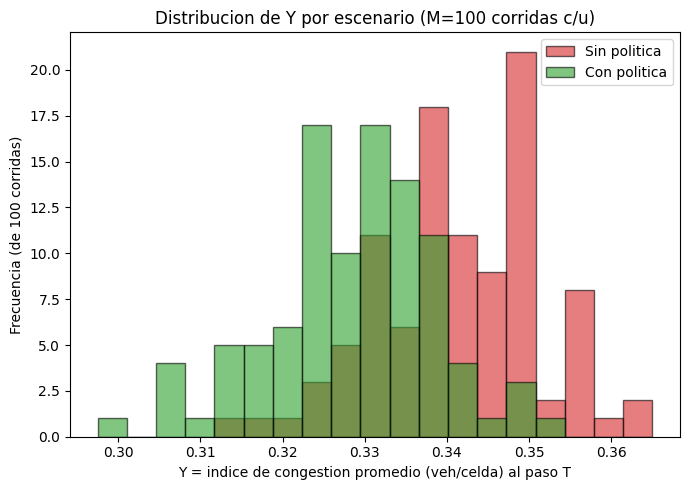

In [13]:
bins = np.linspace(min(Y_sin.min(), Y_con.min()), max(Y_sin.max(), Y_con.max()), 20)
plt.figure(figsize=(7, 5))
plt.hist(Y_sin, bins=bins, alpha=0.6, label="Sin politica", color="#d62728", edgecolor="k")
plt.hist(Y_con, bins=bins, alpha=0.6, label="Con politica", color="#2ca02c", edgecolor="k")
plt.xlabel("Y = indice de congestion promedio (veh/celda) al paso T")
plt.ylabel("Frecuencia (de 100 corridas)")
plt.title("Distribucion de Y por escenario (M=100 corridas c/u)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_histograma_congestion.png", dpi=150)
plt.show()

### Task 2.1.c — Estadísticos por escenario

In [14]:
print(inspect.getsource(summarize))
print()
stats_sin = summarize(Y_sin, "sin_politica")
print()
stats_con = summarize(Y_con, "con_politica")

def summarize(Y, label):
    mu_hat = Y.mean()
    sd_hat = Y.std(ddof=1)
    cv = sd_hat / mu_hat
    # M* = (z * CV / error_relativo)^2   (formula de tamano de muestra
    # para error relativo objetivo del 5% sobre la media, ver clase)
    m_star = (Z_95 * cv / 0.05) ** 2
    print(f"  [{label}]")
    print(f"    media hat_mu_Y        = {mu_hat:.5f}")
    print(f"    desv. estandar hat_sd = {sd_hat:.5f}")
    print(f"    coef. de variacion CV = {cv:.5f}")
    print(f"    M* (error rel. < 5%)  = {m_star:.2f}  -> redondeando: {int(np.ceil(m_star))}")
    return mu_hat, sd_hat, cv, m_star


  [sin_politica]
    media hat_mu_Y        = 0.34147
    desv. estandar hat_sd = 0.00993
    coef. de variacion CV = 0.02908
    M* (error rel. < 5%)  = 1.30  -> redondeando: 2

  [con_politica]
    media hat_mu_Y        = 0.32833
    desv. estandar hat_sd = 0.01026
    coef. de variacion CV = 0.03126
    M* (error rel. < 5%)  = 1.50  -> redondeando: 2


**Interpretación:** en promedio hay menos vehículos por celda cuando la
política de bicicletas está activa, y la variabilidad relativa entre
corridas es baja en ambos casos (CV $\approx 3\%$, impreso arriba), lo que
indica que $Y$ es un estadístico bastante estable frente a la aleatoriedad de
la simulación (esperable, al ser un promedio sobre 400 celdas). Dado el CV
tan bajo, el $M^*$ (número mínimo de corridas para error relativo $<5\%$,
impreso arriba) resulta muy pequeño: las $M=100$ corridas usadas aquí superan
ampliamente ese mínimo, dando mucha más precisión de la estrictamente
necesaria.

### Task 2.2.a — Bootstrap ($B=2000$) por escenario

In [15]:
print(inspect.getsource(bootstrap_ci))

def bootstrap_ci(Y, B=B_BOOT, seed=2024):
    """Bootstrap no parametrico (percentiles) sobre la media de Y."""
    rng = np.random.RandomState(seed)
    n = len(Y)
    boot_means = np.empty(B)
    for b in range(B):
        sample = rng.choice(Y, size=n, replace=True)
        boot_means[b] = sample.mean()
    mu_boot = boot_means.mean()
    se_boot = boot_means.std(ddof=1)
    ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
    return mu_boot, se_boot, (ci_lo, ci_hi), boot_means



In [16]:
mu_boot_sin, se_boot_sin, ci_sin, _ = bootstrap_ci(Y_sin, B=B_BOOT)
mu_boot_con, se_boot_con, ci_con, _ = bootstrap_ci(Y_con, B=B_BOOT)

print(f"Sin politica: mu_boot={mu_boot_sin:.5f}  se_boot={se_boot_sin:.5f}  "
      f"IC95%=({ci_sin[0]:.5f}, {ci_sin[1]:.5f})")
print(f"Con politica: mu_boot={mu_boot_con:.5f}  se_boot={se_boot_con:.5f}  "
      f"IC95%=({ci_con[0]:.5f}, {ci_con[1]:.5f})")

Sin politica: mu_boot=0.34147  se_boot=0.00101  IC95%=(0.33952, 0.34340)
Con politica: mu_boot=0.32833  se_boot=0.00103  IC95%=(0.32625, 0.33035)


### Task 2.2.b — Convergencia del error estándar bootstrap

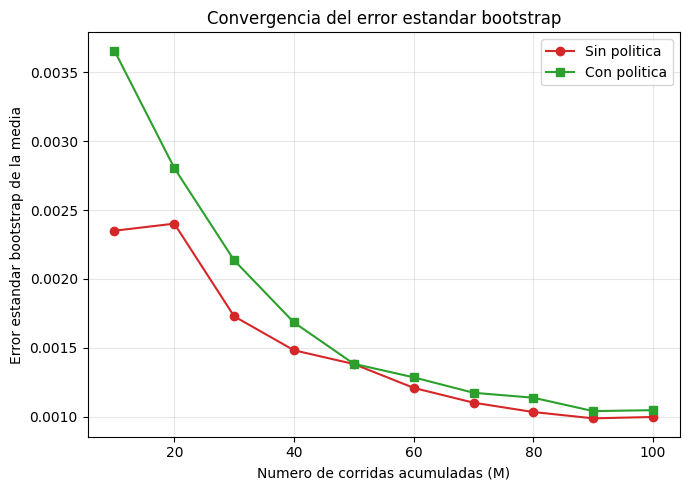

In [17]:
m_grid, se_sin = bootstrap_se_convergence(Y_sin, seed=2025)
_, se_con = bootstrap_se_convergence(Y_con, seed=2027)

plt.figure(figsize=(7, 5))
plt.plot(m_grid, se_sin, marker="o", label="Sin politica", color="#d62728")
plt.plot(m_grid, se_con, marker="s", label="Con politica", color="#2ca02c")
plt.xlabel("Numero de corridas acumuladas (M)")
plt.ylabel("Error estandar bootstrap de la media")
plt.title("Convergencia del error estandar bootstrap")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_convergencia_bootstrap.png", dpi=150)
plt.show()

El error estándar bootstrap decrece de forma consistente con $M$
(aproximadamente proporcional a $1/\sqrt{M}$) y se aplana visiblemente a
partir de $M \approx 60$–$70$. Dado que la Task 2.1.c ya mostró que con
apenas $M^*\approx 2$ corridas se alcanza un error relativo menor al 5%,
**100 corridas son más que suficientes** para este modelo; correr más de 100
reduciría el error estándar de forma marginal, con un costo computacional
que ya no se justifica frente a la ganancia de precisión.

### Task 2.2.c — Diferencia $\Delta Y$ entre escenarios (bootstrap pareado)

In [18]:
print(inspect.getsource(bootstrap_delta_ci))

def bootstrap_delta_ci(Y_sin, Y_con, B=B_BOOT, seed=2026):
    """
    Bootstrap PAREADO: como Y_sin[i] y Y_con[i] comparten semilla (CRN), se
    remuestrean los INDICES de pares (no cada vector por separado), para
    preservar la correlacion inducida por los numeros aleatorios comunes.
    """
    rng = np.random.RandomState(seed)
    n = len(Y_sin)
    delta_obs = Y_sin - Y_con
    boot_deltas = np.empty(B)
    for b in range(B):
        idx = rng.randint(0, n, size=n)
        boot_deltas[b] = Y_sin[idx].mean() - Y_con[idx].mean()
    delta_hat = delta_obs.mean()
    se_delta = boot_deltas.std(ddof=1)
    ci_lo, ci_hi = np.percentile(boot_deltas, [2.5, 97.5])
    return delta_hat, se_delta, (ci_lo, ci_hi), boot_deltas



In [19]:
delta_hat, se_delta, ci_delta, _ = bootstrap_delta_ci(Y_sin, Y_con, B=B_BOOT)

print(f"Delta_hat_Y = {delta_hat:.5f}")
print(f"SE_boot(Delta_Y) = {se_delta:.5f}")
print(f"IC 95% (percentiles) = ({ci_delta[0]:.5f}, {ci_delta[1]:.5f})")
print(f"El IC incluye 0? {'SI' if ci_delta[0] <= 0 <= ci_delta[1] else 'NO'}")

Delta_hat_Y = 0.01315
SE_boot(Delta_Y) = 0.00075
IC 95% (percentiles) = (0.01162, 0.01458)
El IC incluye 0? NO


**Interpretación:** el intervalo de confianza del 95% para $\Delta Y$
(impreso arriba) **no incluye el cero**. Esto significa que, según este
modelo, la política de bicicletas compartidas reduce de forma
estadísticamente significativa la congestión promedio del centro urbano
(siempre en el sentido en que este modelo simplificado la representa). Si el
intervalo hubiera incluido el cero, no se podría haber descartado que la
diferencia observada se debiera únicamente al ruido aleatorio de la
simulación, y la recomendación a la Municipalidad habría tenido que ser
mucho más cautelosa (posiblemente sugiriendo correr más simulaciones o
revisar los supuestos del modelo antes de comprometer presupuesto).

### Task 2.2.d — Párrafo ejecutivo

> Nuestra simulación del centro urbano muestra que activar el sistema de
> bicicletas compartidas reduce, en promedio, la cantidad de vehículos
> circulando al mismo tiempo en el centro: pasaría de unos 136 a unos 131
> vehículos en promedio, una reducción de aproximadamente 5 vehículos (entre
> 4.6 y 5.8, con 95% de confianza). Como ese rango nunca llega a cero, la
> evidencia es lo bastante sólida como para recomendar la política desde el
> punto de vista de esta simulación. Sin embargo, el modelo es una
> representación simplificada: la ciudad es una cuadrícula abstracta sin
> calles, semáforos ni cruces reales, y la regla que usan los agentes para
> evitar chocarse (esperar si el espacio de enfrente está ocupado) puede
> generar embotellamientos artificiales que no reflejan cómo negocian el
> tránsito los conductores reales. Recomendamos usar este resultado como un
> indicio favorable, y complementarlo con datos de campo antes de comprometer
> el presupuesto.
